In [13]:
# Load preprocessed dataset

import pandas as pd

df = pd.read_csv("/content/preprocessed_dataset.csv")

In [14]:
# Load and prepare text for clustering

import pandas as pd

df = pd.read_csv("preprocessed_dataset.csv")

df = df.dropna(subset=["cleaned_text"]).copy()

df["cleaned_text"] = df["cleaned_text"].astype(str)

df = df[df["cleaned_text"].str.strip() != ""].copy()

print("Text prepared successfully")
print("Dataset shape after cleaning:", df.shape)

print("\nMissing cleaned_text values:")
print(df["cleaned_text"].isnull().sum())

print("\nEmpty cleaned_text rows:")
print((df["cleaned_text"].str.strip() == "").sum())

display(df[["title", "category", "cleaned_text"]].head())

Text prepared successfully
Dataset shape after cleaning: (287421, 12)

Missing cleaned_text values:
0

Empty cleaned_text rows:
0


,title,category,cleaned_text
0,Dynamic Backtracking,Artificial Intelligence,dynamic backtrack occasional need return shall...
1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,market orient program environment application ...
2,An Empirical Analysis of Search in GSAT,Artificial Intelligence,empirical analysis search gsat describe extens...
3,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,difficulty learn logic program cut real logic ...
4,Software Agents: Completing Patterns and Const...,Artificial Intelligence,software agent complete pattern construct user...


In [15]:
# Create TF-IDF features for clustering

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.85
)

X_tfidf = tfidf_vectorizer.fit_transform(df["cleaned_text"])

print("TF-IDF features created successfully")
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF features created successfully
TF-IDF matrix shape: (287421, 5000)


In [16]:
# Apply K-Means clustering

from sklearn.cluster import KMeans

kmeans_model = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(X_tfidf)

df["cluster"] = cluster_labels

print("K-Means clustering completed")
print("Number of clusters:", df["cluster"].nunique())

print("\nCluster counts:")
display(df["cluster"].value_counts().sort_index())

K-Means clustering completed
Number of clusters: 10

Cluster counts:


,count
cluster,
0,8539
1,25293
2,5213
3,98241
4,10768
5,34107
6,45573
7,38671
8,11923


In [28]:
# Evaluate clustering using Silhouette Score

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_tfidf,
    cluster_labels,
    sample_size=5000,
    random_state=42
)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.0068


,Number of Clusters,Inertia
0,2,9586.008165
1,3,9544.001356
2,4,9509.644178
3,5,9485.668412
4,6,9459.776784
5,7,9436.354189
6,8,9411.420229
7,9,9394.142899
8,10,9370.964336
9,11,9354.664951


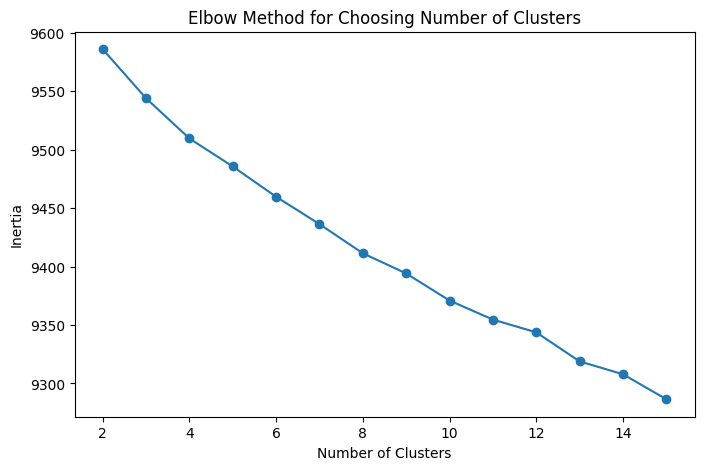

In [17]:
# Find best number of clusters using Elbow Method

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

cluster_range = range(2, 16)
inertia_values = []

if X_tfidf.shape[0] > 10000:
    sample_index = np.random.RandomState(42).choice(
        X_tfidf.shape[0],
        size=10000,
        replace=False
    )
    X_elbow = X_tfidf[sample_index]
else:
    X_elbow = X_tfidf

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_elbow)
    inertia_values.append(kmeans.inertia_)

elbow_results = pd.DataFrame({
    "Number of Clusters": list(cluster_range),
    "Inertia": inertia_values
})

display(elbow_results)

plt.figure(figsize=(8, 5))
plt.plot(list(cluster_range), inertia_values, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing Number of Clusters")
plt.show()

In [18]:
# Add cluster labels to dataset

if len(cluster_labels) == len(df):
    df["cluster"] = cluster_labels

    print("Cluster labels added successfully")
    print("Dataset shape:", df.shape)

    print("\nCluster counts:")
    display(df["cluster"].value_counts().sort_index())

    display(df[["title", "category", "cluster"]].head(10))

else:
    print("Error: Number of cluster labels does not match number of rows in the dataset")
    print("Dataset rows:", len(df))
    print("Cluster labels:", len(cluster_labels))

Cluster labels added successfully
Dataset shape: (287421, 13)

Cluster counts:


,count
cluster,
0,8539
1,25293
2,5213
3,98241
4,10768
5,34107
6,45573
7,38671
8,11923


,title,category,cluster
0,Dynamic Backtracking,Artificial Intelligence,6
1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,6
2,An Empirical Analysis of Search in GSAT,Artificial Intelligence,6
3,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,3
4,Software Agents: Completing Patterns and Const...,Artificial Intelligence,4
5,Decidable Reasoning in Terminological Knowledg...,Artificial Intelligence,3
6,Teleo-Reactive Programs for Agent Control,Artificial Intelligence,4
7,Learning the Past Tense of English Verbs: The ...,Artificial Intelligence,3
8,Substructure Discovery Using Minimum Descripti...,Artificial Intelligence,3
9,Bias-Driven Revision of Logical Domain Theories,Artificial Intelligence,6


In [19]:
# Analyze clusters

import pandas as pd

cluster_summary = df["cluster"].value_counts().sort_index().reset_index()
cluster_summary.columns = ["Cluster", "Number of Papers"]

display(cluster_summary)

category_cluster_table = pd.crosstab(df["cluster"], df["category"])

display(category_cluster_table)

top_categories_per_cluster = {}

for cluster_id in sorted(df["cluster"].unique()):
    top_categories = (
        df[df["cluster"] == cluster_id]["category"]
        .value_counts()
        .head(5)
    )
    top_categories_per_cluster[cluster_id] = top_categories

    print(f"\nCluster {cluster_id} - Top Categories")
    display(top_categories)

,Cluster,Number of Papers
0,0,8539
1,1,25293
2,2,5213
3,3,98241
4,4,10768
5,5,34107
6,6,45573
7,7,38671
8,8,11923
9,9,9093


category,Accelerator Physics,Adaptation and Self-Organizing Systems,Algebraic Geometry,Algebraic Topology,Analysis of PDEs,Applications (Statistics),Applied Physics,Artificial Intelligence,Astrophysics,Astrophysics of Galaxies,...,Tissues and Organs,Trading and Market Microstructure,cond-mat.other,cond-mat.quant-gas,math.AC,math.CA,math.GN,math.RA,physics.atom-ph,physics.pop-ph
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,1,0,104,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,13,3,2,11,19,10,816,0,3,...,2,2,1,0,0,0,2,0,0,0
2,0,0,0,0,0,1,0,175,0,0,...,0,0,0,0,0,0,0,0,0,0
3,8,21,3,5,3,329,17,9991,0,19,...,8,27,0,4,3,0,0,3,2,2
4,0,4,0,0,0,2,2,4928,0,0,...,0,18,0,0,0,0,0,0,0,0
5,0,0,1,0,0,9,1,5976,0,0,...,0,6,0,0,0,0,0,0,0,0
6,6,5,12,9,18,119,7,3994,3,4,...,1,4,0,0,1,8,0,1,0,0
7,0,0,1,0,0,8,1,249,0,6,...,8,0,0,0,0,0,0,0,0,0
8,3,0,1,1,0,9,2,1668,0,0,...,0,8,0,0,0,0,0,0,0,0



Cluster 0 - Top Categories


,count
category,
Computer Vision and Pattern Recognition,7640
Machine Learning,131
Robotics,130
Artificial Intelligence,104
Image and Video Processing,101



Cluster 1 - Top Categories


...

,count
category,
Computer Vision and Pattern Recognition,33649
Image and Video Processing,1720
Machine Learning,939
Robotics,611
Graphics,436



Cluster 8 - Top Categories


,count
category,
Machine Learning,7013
Artificial Intelligence,1668
Robotics,1281
Computation and Language (Natural Language Processing),425
Computer Vision and Pattern Recognition,420



Cluster 9 - Top Categories


,count
category,
Machine Learning,5239
Artificial Intelligence,825
Computer Vision and Pattern Recognition,799
Computation and Language (Natural Language Processing),745
Machine Learning (Statistics),425


In [20]:
# Show top words in each cluster

import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()
cluster_centers = kmeans_model.cluster_centers_

for cluster_id in range(kmeans_model.n_clusters):
    top_word_indices = cluster_centers[cluster_id].argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top_word_indices]

    print(f"Cluster {cluster_id} top words:")
    print(top_words)

Cluster 0 top words:
['video', 'frame', 'temporal', 'motion', 'model', 'action', 'generation', 'object', 'visual', 'method']
Cluster 1 top words:
['network', 'neural', 'deep', 'learn', 'train', 'model', 'layer', 'architecture', 'use', 'data']
Cluster 2 top words:
['attack', 'adversarial', 'defense', 'model', 'robustness', 'perturbation', 'backdoor', 'train', 'example', 'poison']
Cluster 3 top words:
['model', 'data', 'learn', 'use', 'system', 'train', 'base', 'method', 'task', 'ai']
Cluster 4 top words:
['agent', 'llm', 'multi', 'ai', 'system', 'task', 'environment', 'model', 'reason', 'human']
Cluster 5 top words:
['llm', 'language', 'model', 'reason', 'large', 'task', 'prompt', 'question', 'tune', 'answer']
Cluster 6 top words:
['algorithm', 'problem', 'learn', 'data', 'method', 'optimization', 'sample', 'function', 'model', 'use']
Cluster 7 top words:
['image', '3d', 'object', 'segmentation', 'model', 'method', 'feature', 'scene', 'detection', 'train']
Cluster 8 top words:
['policy'

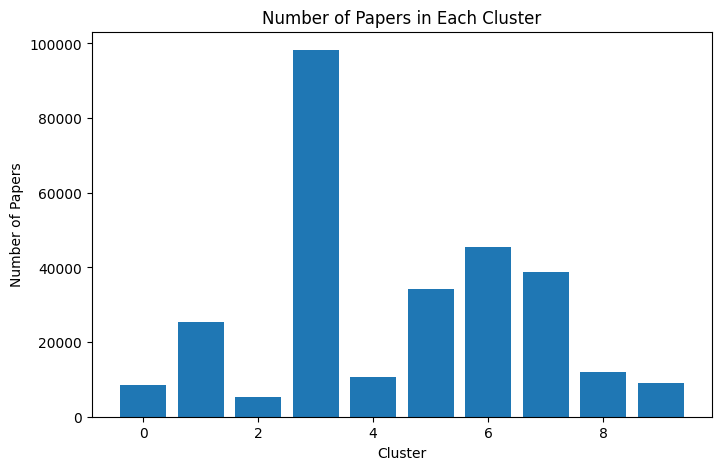

In [25]:
# Visualize cluster counts

import matplotlib.pyplot as plt

cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Papers")
plt.title("Number of Papers in Each Cluster")
plt.show()

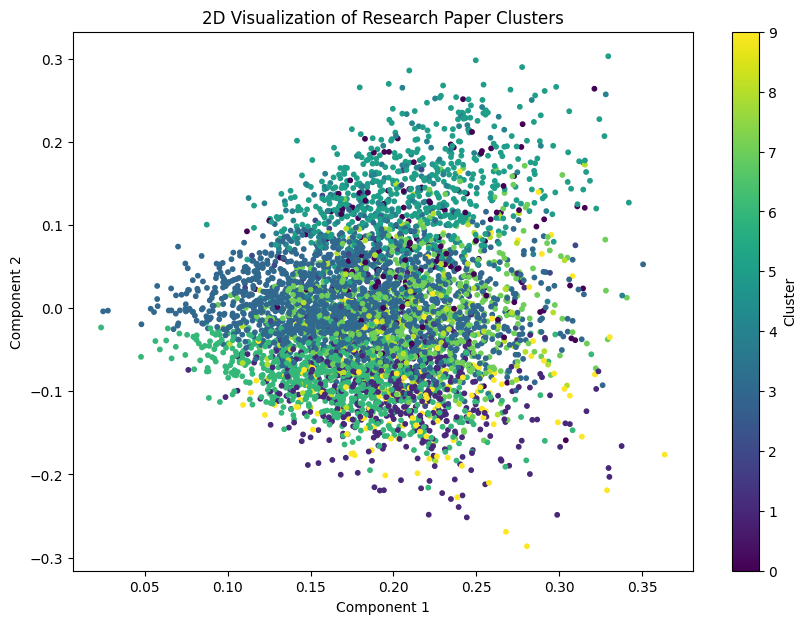

In [26]:
# Visualize clusters in 2D

from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt

sample_size = min(5000, X_tfidf.shape[0])

sample_indices = np.random.RandomState(42).choice(
    X_tfidf.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_tfidf[sample_indices]
cluster_sample = df["cluster"].iloc[sample_indices]

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_sample)

plt.figure(figsize=(10, 7))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_sample, s=10)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("2D Visualization of Research Paper Clusters")
plt.colorbar(label="Cluster")
plt.show()

In [27]:
# Save clustering model and TF-IDF vectorizer

import pickle

with open("kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans_model, file)

with open("clustering_tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf_vectorizer, file)

print("Clustering model and vectorizer saved successfully")

Clustering model and vectorizer saved successfully


In [ ]:
# Save the final clustered dataset

clustered_dataset = df.copy()

clustered_dataset.to_csv(
    "clustered_dataset.csv",
    index=False
)

print("Clustered dataset saved successfully")
print("File name: clustered_dataset.csv")
print("Dataset shape:", clustered_dataset.shape)

print("\nCluster counts:")
display(clustered_dataset["cluster"].value_counts().sort_index())

display(
    clustered_dataset[
        ["title", "category", "cleaned_text", "cluster"]
    ].head(10)
)